# Captura del Osciloscopio - 802.11g

![Captura en el osciloscopio](capturas/setup.png)

Procesamiento completo: carga -> espectro -> banda base -> decimacion -> deteccion de STS

## 1. Carga de datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import decimate
from scipy.ndimage import uniform_filter1d

df = pd.read_csv("capturas/80211g.csv", usecols=[3, 4], header=None)
#df = pd.read_csv("capturas/sinabsorventes.csv", usecols=[3, 4], header=None)
#df = pd.read_csv("capturas/conabsorventes.csv", usecols=[3, 4], header=None)
t = df[3].to_numpy()
x = df[4].to_numpy()

ts = t[1] - t[0]
fs = 1 / ts
print(f"Frecuencia de muestreo: {fs/1e9:.3f} GSa/s")
print(f"Duracion de la captura: {t[-1]*1e6:.1f} us")
print(f"Numero de muestras:     {len(t)}")

Frecuencia de muestreo: 25.000 GSa/s
Duracion de la captura: 670.0 us
Numero de muestras:     25000000


## 2. Senal en el tiempo

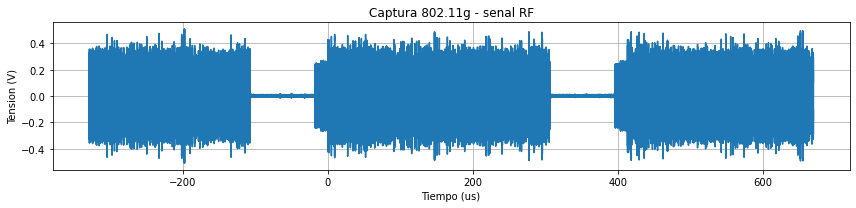

In [2]:
plt.figure(figsize=(12, 3))
plt.plot(t * 1e6, x)
plt.xlabel("Tiempo (us)")
plt.ylabel("Tension (V)")
plt.title("Captura 802.11g - senal RF")
plt.grid()
plt.tight_layout()
plt.show()

## 3. Espectro de la senal RF

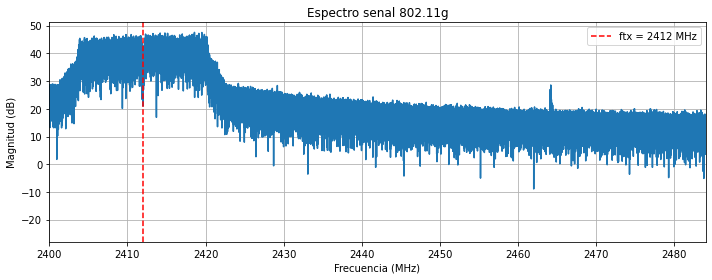

In [3]:
espectro = np.abs(np.fft.fft(x))
espectro = espectro[:len(espectro) // 2]
frecuencia = np.linspace(0, fs / 2, len(espectro))

ftx = 2412e6  # Canal 6 de 802.11g

plt.figure(figsize=(10, 4))
plt.plot(frecuencia / 1e6, 10 * np.log10(espectro + 1e-10))
plt.xlabel("Frecuencia (MHz)")
plt.ylabel("Magnitud (dB)")
plt.title("Espectro senal 802.11g")
plt.xlim(2400, 2484)
plt.axvline(ftx / 1e6, color='r', linestyle='--', label=f'ftx = {ftx/1e6:.0f} MHz')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

## 4. Bajada a banda base y decimacion

Se multiplica por exp(-j*2*pi*ftx*t) para centrar la senal en DC,
luego se decima de 25 GSa/s a 20 MSa/s (factor 1250 = 2x5x5x5x5).

**Importante:** la decimacion se hace en etapas para evitar problemas numericos.

In [4]:
# Mezcla con portadora
complex_bb = x * np.exp(-1j * 2 * np.pi * ftx * t)

# Decimacion en etapas: 1250 = 2 x 5 x 5 x 5 x 5
s_bb = complex_bb.copy()
for factor in [2, 5, 5, 5, 5]:
    s_bb = decimate(s_bb, factor, ftype='fir', zero_phase=True)

fs_20M = fs / 1250
t_20M = np.arange(len(s_bb)) / fs_20M

print(f"fs original: {fs/1e9:.3f} GSa/s")
print(f"fs decimada: {fs_20M/1e6:.3f} MSa/s")
print(f"Muestras IQ: {len(s_bb)}")

fs original: 25.000 GSa/s
fs decimada: 20.000 MSa/s
Muestras IQ: 20000


## 5. Verificacion del espectro en banda base

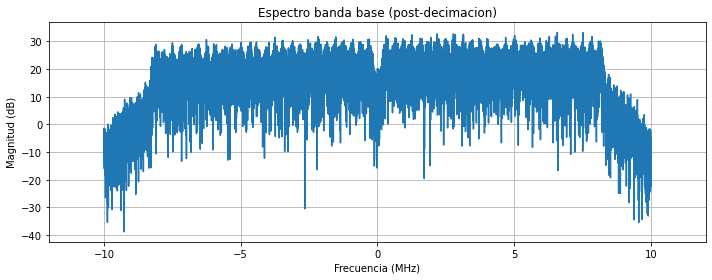

In [5]:
espectro_bb = np.abs(np.fft.fftshift(np.fft.fft(s_bb)))
freqs_bb = np.linspace(-fs_20M / 2, fs_20M / 2, len(espectro_bb)) / 1e6

plt.figure(figsize=(10, 4))
plt.plot(freqs_bb, 20 * np.log10(espectro_bb + 1e-10))
plt.xlabel("Frecuencia (MHz)")
plt.ylabel("Magnitud (dB)")
plt.title("Espectro banda base (post-decimacion)")
plt.xlim(-12, 12)
plt.grid()
plt.tight_layout()
plt.show()

## 6. Deteccion de bursts

Se calcula la energia suavizada para identificar los bursts.
El **primer burst** se descarta: la captura empieza en el medio de ese frame (sin STS completa).

Bursts detectados: 2
  Burst 0: muestra      0 ->   4455  (222.8 us)
  Burst 1: muestra   6242 ->  12725  (324.2 us)

Nota: el Burst 0 se descarta (frame incompleto, sin STS)


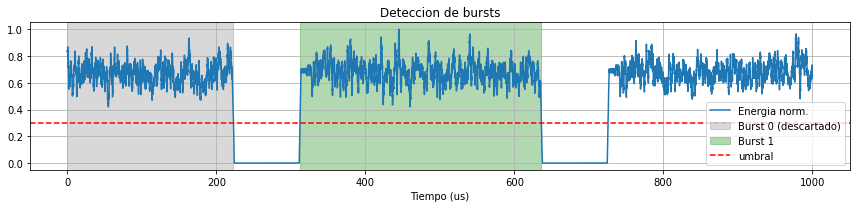

In [6]:
# Energia suavizada
energia = np.abs(s_bb) ** 2
energia_suave = uniform_filter1d(energia, size=50)
energia_norm = energia_suave / np.max(energia_suave)

# Umbral: por encima = burst, por debajo = silencio
umbral_energia = 0.3 * np.max(energia_suave)
en_burst = energia_norm > 0.3

cambios = np.diff(en_burst.astype(int))
inicios_burst = np.where(cambios == 1)[0]   # subida: empieza burst
fines_burst   = np.where(cambios == -1)[0]  # bajada: termina burst

# Si la senal empieza ya dentro de un burst, agregar inicio en 0
if en_burst[0]:
    inicios_burst = np.concatenate(([0], inicios_burst))

n_bursts = min(len(inicios_burst), len(fines_burst))
inicios_burst = inicios_burst[:n_bursts]
fines_burst   = fines_burst[:n_bursts]

print(f"Bursts detectados: {n_bursts}")
for i, (ini, fin) in enumerate(zip(inicios_burst, fines_burst)):
    duracion = (fin - ini) / fs_20M * 1e6
    print(f"  Burst {i}: muestra {ini:6d} -> {fin:6d}  ({duracion:.1f} us)")
print()
print("Nota: el Burst 0 se descarta (frame incompleto, sin STS)")

plt.figure(figsize=(12, 3))
plt.plot(t_20M * 1e6, energia_norm, label='Energia norm.')
for i, (ini, fin) in enumerate(zip(inicios_burst, fines_burst)):
    color = 'gray' if i == 0 else 'green'
    label = f'Burst {i}' + (' (descartado)' if i == 0 else '')
    plt.axvspan(t_20M[ini] * 1e6, t_20M[fin] * 1e6, alpha=0.3, color=color, label=label)
plt.axhline(0.3, color='red', linestyle='--', label='umbral')
plt.xlabel("Tiempo (us)")
plt.title("Deteccion de bursts")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


## 7. Deteccion de STS con Schmidl-Cox

La STS de 802.11g tiene 10 simbolos cortos identicos de N=16 muestras a 20 MHz.
La metrica M(d) = |P(d)|^2 / R(d)^2 forma una meseta al encontrar esa estructura.

In [7]:
def schmidl_cox_metric(iq_signal, N=16):
    L = len(iq_signal)
    ventana = np.ones(N)
    prod = np.conj(iq_signal[:-N]) * iq_signal[N:]
    P = np.convolve(prod, ventana, mode='valid')
    energy = np.abs(iq_signal[N:]) ** 2
    R = np.convolve(energy, ventana, mode='valid')
    P = P[:L - 2 * N]
    R = R[:L - 2 * N]
    M = np.abs(P) ** 2 / (R ** 2 + 1e-10)
    return M, P, R

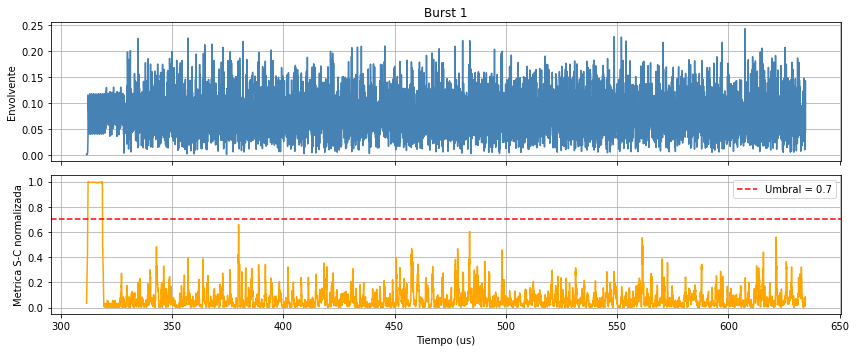

Burst 1: STS detectada
  Inicio STS (muestra abs): 6244
  Fin burst  (muestra abs): 12725
  Tiempo STS:               312.200 us
  Duracion del frame:       324.1 us
  Muestras del frame:       6481


In [8]:
N = 16
umbral_sc = 0.7

# Variables que se llevan fuera del loop
frame = None
P_global = None
indices_sts_global = None
M_norm_global = None

# Saltear el primer burst (incompleto)
for i, (ini, fin) in enumerate(zip(inicios_burst[1:], fines_burst[1:]), start=1):
    ini_ext = max(0, ini - int(0.5e-6 * fs_20M))
    segmento = s_bb[ini_ext:fin]

    if len(segmento) < 4 * N:
        print(f"Burst {i}: demasiado corto, se omite")
        continue

    M, P, R = schmidl_cox_metric(segmento, N)
    M_norm = M / np.max(M)
    t_seg = t_20M[ini_ext : ini_ext + len(M_norm)]

    fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
    axes[0].plot(t_seg * 1e6, np.abs(segmento[:len(M_norm)]), color='steelblue')
    axes[0].set_ylabel("Envolvente")
    axes[0].set_title(f"Burst {i}")
    axes[0].grid()
    axes[1].plot(t_seg * 1e6, M_norm, color='orange', linewidth=1.5)
    axes[1].axhline(umbral_sc, color='red', linestyle='--', label=f'Umbral = {umbral_sc}')
    axes[1].set_ylabel("Metrica S-C normalizada")
    axes[1].set_xlabel("Tiempo (us)")
    axes[1].legend()
    axes[1].grid()
    plt.tight_layout()
    plt.show()

    indices_sts = np.where(M_norm > umbral_sc)[0]
    if len(indices_sts) > 0:
        muestra_local = indices_sts[0]
        muestra_abs   = ini_ext + muestra_local
        t_sts         = t_20M[muestra_abs] * 1e6
        print(f"Burst {i}: STS detectada")
        print(f"  Inicio STS (muestra abs): {muestra_abs}")
        print(f"  Fin burst  (muestra abs): {fin}")
        print(f"  Tiempo STS:               {t_sts:.3f} us")

        # Frame recortado: desde inicio de STS hasta fin del burst
        frame = s_bb[muestra_abs : fin]
        print(f"  Duracion del frame:       {len(frame)/fs_20M*1e6:.1f} us")
        print(f"  Muestras del frame:       {len(frame)}")

        # Guardar para celdas siguientes
        P_global = P
        indices_sts_global = indices_sts
        M_norm_global = M_norm
        break  # procesar solo el primer burst completo con STS
    else:
        max_m = np.max(M_norm)
        print(f"Burst {i}: STS NO detectada (max metrica = {max_m:.3f})")
        print(f"  -> proba bajar el umbral a {max_m*0.8:.2f}")
    print()

# Alias para celdas siguientes
P           = P_global
indices_sts = indices_sts_global
M_norm      = M_norm_global
assert frame is not None, "No se detecto ninguna STS"


## 8. Estimación del error de frecuencia (CFO) y la relación señal a ruido (SNR)

In [9]:
# CFO estimation using STS
# La STS tiene 10 simbolos cortos de N=16 muestras
# El angulo de P(d) en la meseta es proporcional al CFO

# Tomar P en la zona de la meseta (donde M_norm > umbral)
P_meseta = P[indices_sts]

# CFO normalizado (en radianes por muestra)
cfo_rad = np.angle(np.mean(P_meseta)) / N

# CFO en Hz
cfo_hz = cfo_rad * fs_20M / (2 * np.pi)

print(f"CFO estimado: {cfo_hz:+.1f} Hz  ({cfo_rad*1e3:+.3f} mrad/muestra)")

# Correccion del CFO en el frame completo
t_frame = np.arange(len(frame)) / fs_20M
frame_corr = frame * np.exp(-1j * 2 * np.pi * cfo_hz * t_frame)

CFO estimado: -1873.2 Hz  (-0.588 mrad/muestra)


In [10]:
# SNR estimation using STS
# Señal: promedio coherente de los 10 simbolos cortos
# Ruido: diferencia entre cada simbolo y el promedio

# Extraer los 10 simbolos cortos del frame corregido (primeras 160 muestras)
sts = frame_corr[:10 * N].reshape(10, N)

# Promedio coherente = estimacion de la señal
s_ref = np.mean(sts, axis=0)

# Ruido = diferencia entre cada simbolo y la referencia
ruido = sts - s_ref
P_senal = np.mean(np.abs(s_ref) ** 2)
P_ruido  = np.mean(np.abs(ruido) ** 2)

snr_lineal = P_senal / P_ruido
snr_db     = 10 * np.log10(snr_lineal)

print(f"SNR estimada: {snr_db:.1f} dB")

SNR estimada: 19.1 dB


Potencia antes del AGC: 0.0079
Potencia despues:       1.0000  (debe ser ~1.0)


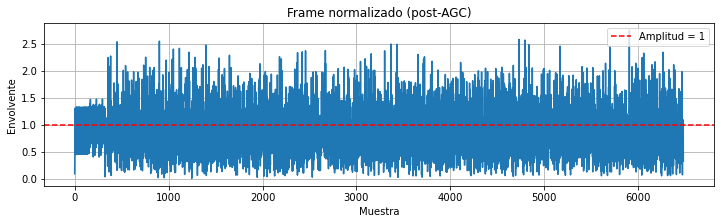

In [11]:
# Normalizacion AGC: escalar frame para que la potencia media sea 1
# (portadoras BPSK quedaran cerca de +1/-1)

P_frame = np.mean(np.abs(frame_corr) ** 2)
gain_agc = 1.0 / np.sqrt(P_frame)
frame_norm = frame_corr * gain_agc

print(f"Potencia antes del AGC: {P_frame:.4f}")
print(f"Potencia despues:       {np.mean(np.abs(frame_norm)**2):.4f}  (debe ser ~1.0)")

# Verificacion visual: envolvente del frame normalizado
plt.figure(figsize=(12, 3))
plt.plot(np.abs(frame_norm))
plt.axhline(1.0, color='red', linestyle='--', label='Amplitud = 1')
plt.xlabel("Muestra")
plt.ylabel("Envolvente")
plt.title("Frame normalizado (post-AGC)")
plt.legend()
plt.grid()
plt.show()

## 9. Estimacion de la respuesta del canal en base a la LTS

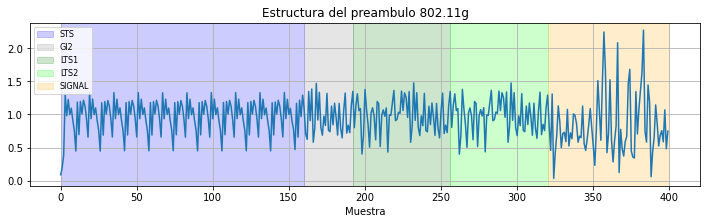

In [12]:
# Verificar alineacion del LTS
plt.figure(figsize=(12, 3))
plt.plot(np.abs(frame_norm[:400]))
plt.axvspan(0,        160,       alpha=0.2, color='blue',  label='STS')
plt.axvspan(160,      192,       alpha=0.2, color='gray',  label='GI2')
plt.axvspan(192,      256,       alpha=0.2, color='green', label='LTS1')
plt.axvspan(256,      320,       alpha=0.2, color='lime',  label='LTS2')
plt.axvspan(320,      400,       alpha=0.2, color='orange',label='SIGNAL')
plt.legend(fontsize=8)
plt.xlabel("Muestra")
plt.title("Estructura del preambulo 802.11g")
plt.grid()
plt.show()

LTS_REF tiene 64 elementos
CFO fino: +2954.6 Hz


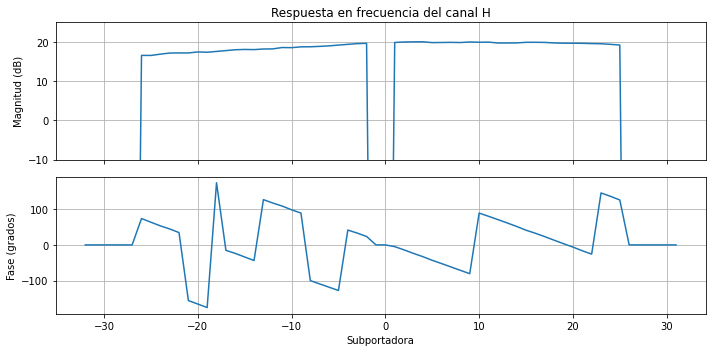

Canal estimado y frame listo para demodulacion.


In [13]:
# LTS correcto segun estandar 802.11-2007, tabla 18-7
# Orden natural: subportadora 0, +1, ..., +31, -32, ..., -1
LTS_FREQ = np.array([
     0, 1,-1,-1, 1, 1,-1, 1,-1, 1, 1, 1, 1, 1, 1,-1,
    -1, 1, 1,-1, 1,-1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
     0, 0, 0, 0, 0, 0,-1,-1, 1, 1,-1, 1,-1, 1,-1,-1,
    -1,-1,-1, 1, 1,-1,-1, 1,-1, 1,-1, 1, 1, 1, 1, 0
], dtype=complex)
print(f"LTS_REF tiene {len(LTS_FREQ)} elementos")

# Extraer el LTS del frame normalizado
N_STS = 10 * 16
N_GI2 = 32
N_LTS = 64

lts_raw = frame_norm[N_STS + N_GI2 : N_STS + N_GI2 + 2 * N_LTS]
lts1 = lts_raw[:N_LTS]
lts2 = lts_raw[N_LTS:]

LTS1_rx = np.fft.fft(lts1, N_LTS)
LTS2_rx = np.fft.fft(lts2, N_LTS)

# CFO fino sobre subportadoras activas
activas_lts = np.where(LTS_FREQ != 0)[0]
diff_fase = LTS2_rx[activas_lts] * np.conj(LTS1_rx[activas_lts])
cfo_fino_rad = np.angle(np.mean(diff_fase)) / N_LTS
cfo_fino_hz  = cfo_fino_rad * fs_20M / (2 * np.pi)
print(f"CFO fino: {cfo_fino_hz:+.1f} Hz")

# Aplicar CFO fino
t_frame2 = np.arange(len(frame_norm)) / fs_20M
frame_norm = frame_norm * np.exp(-1j * 2 * np.pi * cfo_fino_hz * t_frame2)

# Re-extraer LTS con frame corregido
lts_raw = frame_norm[N_STS + N_GI2 : N_STS + N_GI2 + 2 * N_LTS]
lts1 = lts_raw[:N_LTS]
lts2 = lts_raw[N_LTS:]

# Estimacion de canal: evitar division por cero
LTS1_rx = np.fft.fft(lts1, N_LTS)
LTS2_rx = np.fft.fft(lts2, N_LTS)
LTS_rx  = (LTS1_rx + LTS2_rx) / 2
H = np.zeros(N_LTS, dtype=complex)
H[activas_lts] = LTS_rx[activas_lts] / LTS_FREQ[activas_lts]

# Visualizacion del canal
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
subportadoras = np.fft.fftshift(np.arange(N_LTS) - N_LTS//2)
H_shift = np.fft.fftshift(H)
axes[0].plot(np.arange(-32, 32), 20 * np.log10(np.abs(H_shift) + 1e-10))
axes[0].set_ylabel("Magnitud (dB)")
axes[0].set_title("Respuesta en frecuencia del canal H")
axes[0].grid()
axes[0].set_ylim([-10,25])
axes[1].plot(np.arange(-32, 32), np.degrees(np.angle(H_shift)))
axes[1].set_ylabel("Fase (grados)")
axes[1].set_xlabel("Subportadora")
axes[1].grid()
plt.tight_layout()
plt.show()
print("Canal estimado y frame listo para demodulacion.")

# 10. Decodificacion
## 10.1 Campo Signal

SIGNAL field (1 símbolo OFDM, BPSK r=1/2):
- bits 0-3:  RATE (modulación + code rate)
- bit  4:    reservado
- bits 5-16: LENGTH (largo del PSDU en bytes)
- bit  17:   paridad (par)
- bits 18-23: tail (zeros)

Subportadoras de datos: 48
DC incluido: False
Pilotos incluidos: False
48 bits raw del campo SIGNAL:
[0 0 1 0 1 0 1 0 1 0 1 0 0 1 0 0 1 0 1 0 1 1 1 0 0 1 0 1 1 0 1 1 1 0 0 0 1
 0 0 1 0 1 1 0 0 1 1 0]


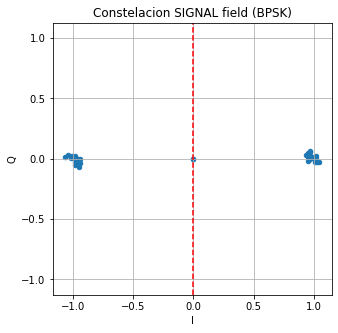

In [14]:
# Demodulacion del campo SIGNAL
# Ubicacion: justo despues de STS + GI2 + 2*LTS
N_CP_SIGNAL = 16   # prefijo ciclico
N_FFT       = 64

inicio_signal = N_STS + N_GI2 + 2 * N_LTS
signal_sym = frame_norm[inicio_signal + N_CP_SIGNAL : inicio_signal + N_CP_SIGNAL + N_FFT]

# FFT y ecualizacion
S = np.fft.fft(signal_sym, N_FFT)
S_eq = np.zeros(N_FFT, dtype=complex)
S_eq[activas_lts] = S[activas_lts] / H[activas_lts]

# Subportadoras de datos (excluir pilotos en ±7, ±21)
# Subportadoras activas en orden: -26..-1, 1..26 (indices FFT)
#data_idx  = list(range(38, 64)) + list(range(1, 27))  # -26..-1, +1..+26
#pilot_idx = [43, 57, 7, 21]                            # -21, -7, +7, +21
#data_idx  = [i for i in data_idx if i not in pilot_idx]

# Subportadoras de datos del campo SIGNAL (48 subportadoras)
# -26..-1 → indices FFT 38..63  (excluyendo DC=0)
# +1..+26 → indices FFT  1..26
# Pilotos en 7, 21, 43, 57 → excluir
# DC en indice 0 → excluir (ya excluido por range(1,27) y range(38,64))

data_idx  = list(range(38, 64)) + list(range(1, 27))
pilot_idx = [43, 57, 7, 21]
data_idx  = [i for i in data_idx if i not in pilot_idx]

print(f"Subportadoras de datos: {len(data_idx)}")  # debe ser 48
print(f"DC incluido: {0 in data_idx}")              # debe ser False
print(f"Pilotos incluidos: {any(p in data_idx for p in pilot_idx)}")  # debe ser False
# Extraer 48 subportadoras de datos
S_data = S_eq[data_idx]

# El campo SIGNAL usa BPSK: decidir por signo de la parte real
bits_raw = (S_data.real < 0).astype(int)


print(f"48 bits raw del campo SIGNAL:")
print(bits_raw)

# Visualizacion de la constelacion BPSK
plt.figure(figsize=(5, 5))
plt.scatter(S_data.real, S_data.imag, s=20)
plt.axvline(0, color='red', linestyle='--')
plt.xlabel("I")
plt.ylabel("Q")
plt.title("Constelacion SIGNAL field (BPSK)")
plt.axis('equal')
plt.grid()
plt.show()

In [15]:
# Identificar que subportadora genera el punto en (0,0)
S_data_full = S_eq[data_idx]
for i, (idx, val) in enumerate(zip(data_idx, S_data_full)):
    if np.abs(val) < 0.1:
        print(f"Subportadora idx={idx} -> valor={val:.4f}  (posicion en data_idx={i})")

Subportadora idx=63 -> valor=0.0000+0.0000j  (posicion en data_idx=23)
Subportadora idx=26 -> valor=0.0000+0.0000j  (posicion en data_idx=47)


In [16]:
# Desentrelazado del campo SIGNAL (BPSK, NCBPS=48, NBPSC=1)
# Segun IEEE 802.11-2007 seccion 17.3.5.6

NCBPS = 48   # bits por simbolo OFDM para BPSK
NBPSC = 1    # bits por subportadora para BPSK
s = max(NBPSC // 2, 1)  # s=1 para BPSK

# Primera permutacion inversa: i -> k
# k = (NCBPS/16) * (i % 16) + floor(i/16)
def deinterleave_signal(bits, NCBPS=48, NBPSC=1):
    s = max(NBPSC // 2, 1)
    
    # Permutacion inversa de la segunda permutacion
    # j -> i: invertir j = s*floor(i/s) + (i + floor(16*i/NCBPS)) % s
    j = np.arange(NCBPS)
    i_step1 = np.zeros(NCBPS, dtype=int)
    for i in range(NCBPS):
        jj = (s * (i // s) + (i + int(16 * i / NCBPS)) % s) % NCBPS
        i_step1[jj] = i
    bits_step1 = bits[i_step1]
    
    # Permutacion inversa de la primera permutacion
    # k -> i: invertir k = (NCBPS/16)*(i%16) + floor(i/16)
    k = np.arange(NCBPS)
    i_step2 = np.zeros(NCBPS, dtype=int)
    for i in range(NCBPS):
        kk = (NCBPS // 16) * (i % 16) + i // 16
        i_step2[kk] = i
    bits_step2 = bits_step1[i_step2]
    
    return bits_step2

bits_deint = deinterleave_signal(bits_raw)
print("Bits desentrelazados:")
print(bits_deint)

Bits desentrelazados:
[0 1 1 0 0 0 1 1 0 0 0 0 1 1 1 0 1 0 1 1 0 0 0 1 1 0 0 0 1 1 1 0 1 0 1 0 0
 1 0 1 0 1 0 1 1 0 1 0]


In [17]:
# Decodificador Viterbi rate 1/2
# Polinomios generadores: g0=133, g1=171 (octal) = 0b1011011, 0b1111001
# Constraint length K=7, memoria=6

def viterbi_decode(bits, K=7, g0=0b1011011, g1=0b1111001):
    """
    Decodificador Viterbi para codigo convolucional rate 1/2.
    Entrada: bits entrelazados como pares [b0, b1, b0, b1, ...]
    Salida: bits de informacion decodificados
    """
    n_states = 2 ** (K - 1)  # 64 estados
    INF = float('inf')

    # Precomputar salidas para cada estado y bit de entrada
    def conv_output(state, inp):
        reg = (inp << (K-1)) | state
        b0 = bin(reg & g0).count('1') % 2
        b1 = bin(reg & g1).count('1') % 2
        next_state = (inp << (K-2)) | (state >> 1)
        return next_state, b0, b1

    # Inicializar
    n_pairs = len(bits) // 2
    metrics = np.full(n_states, INF)
    metrics[0] = 0
    paths = np.zeros((n_pairs, n_states), dtype=int)
    prev_states = np.zeros((n_pairs, n_states), dtype=int)

    for t in range(n_pairs):
        rx0 = bits[2*t]
        rx1 = bits[2*t + 1]
        new_metrics = np.full(n_states, INF)

        for state in range(n_states):
            if metrics[state] == INF:
                continue
            for inp in [0, 1]:
                next_s, b0, b1 = conv_output(inp, state)
                # Distancia de Hamming
                dist = (b0 ^ rx0) + (b1 ^ rx1)
                m = metrics[state] + dist
                if m < new_metrics[next_s]:
                    new_metrics[next_s] = m
                    paths[t, next_s] = inp
                    prev_states[t, next_s] = state

        metrics = new_metrics

    # Traceback desde el estado con menor metrica
    decoded = np.zeros(n_pairs, dtype=int)
    state = np.argmin(metrics)
    for t in range(n_pairs - 1, -1, -1):
        decoded[t] = paths[t, state]
        state = prev_states[t, state]

    return decoded

bits_decoded = viterbi_decode(bits_deint)
print(f"Bits decodificados ({len(bits_decoded)}):")
print(bits_decoded)
print(f"Tail bits (ultimos 6, deben ser 0): {bits_decoded[-6:]}")

Bits decodificados (24):
[0 0 0 1 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0]
Tail bits (ultimos 6, deben ser 0): [0 0 0 0 0 0]


In [18]:
# Parseo del campo SIGNAL
# bits 0-3:  RATE
# bit  4:    reservado
# bits 5-16: LENGTH (12 bits, LSB primero)
# bit  17:   paridad
# bits 18-23: tail (zeros)

# Parseo del campo SIGNAL
info_bits = bits_decoded[:18]

# RATE (bits 0-3, MSB primero)
rate_bits = info_bits[0:4]
rate_code = rate_bits[0]*8 + rate_bits[1]*4 + rate_bits[2]*2 + rate_bits[3]

rate_table = {
    0b1101: ("BPSK",   "1/2",  6),
    0b1111: ("BPSK",   "3/4",  9),
    0b0101: ("QPSK",   "1/2", 12),
    0b0111: ("QPSK",   "3/4", 18),
    0b1001: ("16-QAM", "1/2", 24),
    0b1011: ("16-QAM", "3/4", 36),
    0b0001: ("64-QAM", "2/3", 48),
    0b0011: ("64-QAM", "3/4", 54),
}

mod, code_rate, mbps = rate_table.get(rate_code, ("?", "?", 0))

# LENGTH (bits 5-16, LSB primero)
length_bits = info_bits[5:17]
length = sum(b << i for i, b in enumerate(length_bits))

# Paridad (bit 17): paridad par sobre bits 0-16
paridad_calc = np.sum(info_bits[0:17]) % 2
paridad_rx   = info_bits[17]
paridad_ok   = (paridad_calc == paridad_rx)

print(f"RATE code:  {rate_code:04b}")
print(f"Modulacion: {mod}")
print(f"Code rate:  {code_rate}")
print(f"Data rate:  {mbps} Mbps")
print(f"LENGTH:     {length} bytes")
print(f"Paridad:    {'OK' if paridad_ok else 'ERROR'}")

RATE code:  0001
Modulacion: 64-QAM
Code rate:  2/3
Data rate:  48 Mbps
LENGTH:     530 bytes
Paridad:    OK


Simbolos de datos disponibles: 76


/tmp/ipykernel_31336/3094447599.py:26: RuntimeWarning: divide by zero encountered in true_divide
  S_eq[data_idx] = S[data_idx] / H[data_idx]


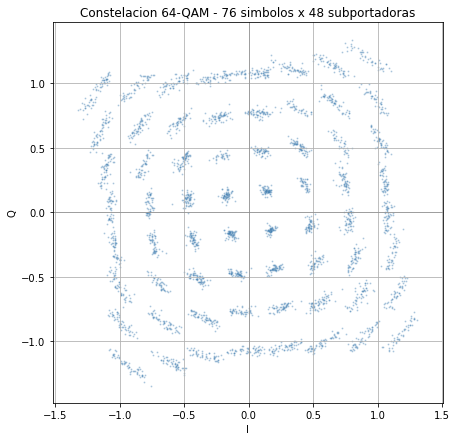

Puntos totales: 3648


In [19]:
# Demodulacion de los simbolos de datos (64-QAM)
N_CP  = 16
N_FFT = 64

# Subportadoras de datos (48) y pilotos (4)
data_idx  = list(range(38, 64)) + list(range(1, 27))
pilot_idx = [43, 57, 7, 21]
data_idx  = [i for i in data_idx if i not in pilot_idx]

# Inicio de los simbolos de datos: STS + GI2 + 2*LTS + SIGNAL
inicio_datos = N_STS + N_GI2 + 2 * N_LTS + (N_CP + N_FFT)

# Cuantos simbolos entran en el frame
muestras_disponibles = len(frame_norm) - inicio_datos
N_simbolos = muestras_disponibles // (N_CP + N_FFT)
print(f"Simbolos de datos disponibles: {N_simbolos}")

# Demodular cada simbolo
constelacion = []
for k in range(N_simbolos):
    offset = inicio_datos + k * (N_CP + N_FFT)
    simbolo = frame_norm[offset + N_CP : offset + N_CP + N_FFT]
    S = np.fft.fft(simbolo, N_FFT)
    # Ecualizar
    S_eq = np.zeros(N_FFT, dtype=complex)
    S_eq[data_idx] = S[data_idx] / H[data_idx]
    constelacion.append(S_eq[data_idx])

constelacion = np.array(constelacion)
puntos = constelacion.flatten()

# Visualizacion
plt.figure(figsize=(7, 7))
plt.scatter(puntos.real, puntos.imag, s=1, alpha=0.3, color='steelblue')
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.xlabel("I")
plt.ylabel("Q")
plt.title(f"Constelacion 64-QAM - {N_simbolos} simbolos x 48 subportadoras")
plt.axis('equal')
plt.grid()
plt.show()

print(f"Puntos totales: {len(puntos)}")

Subportadoras activas en LTS_FREQ: 52  (deben ser 52)


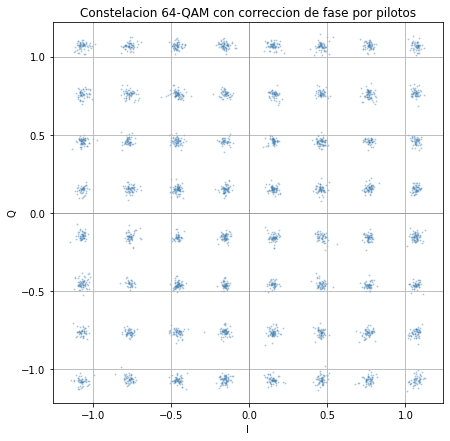

In [20]:
# Correccion de fase simbolo a simbolo usando pilotos
# Pilotos en indices FFT: 7, 21, 43, 57 (+7, +21, -21, -7)
# Valores de referencia: [+1, +1, +1, -1] * secuencia_pn

# Secuencia PN de los pilotos (127 bits, polinomio x^7+x^4+1)
def pilot_pn_sequence(length):
    reg = np.ones(7, dtype=int)
    seq = []
    for _ in range(length):
        seq.append(reg[6])
        feedback = reg[6] ^ reg[3]
        reg = np.roll(reg, 1)
        reg[0] = feedback
    return np.array(seq)

# Corregir LTS_FREQ y recalcular H
LTS_FREQ[26] = -1+0j   # subportadora +26
LTS_FREQ[63] =  1+0j   # subportadora -1
activas_lts = np.where(LTS_FREQ != 0)[0]
H = np.zeros(N_LTS, dtype=complex)
H[activas_lts] = LTS_rx[activas_lts] / LTS_FREQ[activas_lts]
print(f"Subportadoras activas en LTS_FREQ: {len(activas_lts)}  (deben ser 52)")

# Parametros de pilotos
pn = pilot_pn_sequence(N_simbolos + 1)
pilot_ref         = np.array([1, 1, 1, -1])
pilot_idx_ordered = [7, 21, 43, 57]

# Demodulacion con ecualizacion y correccion de fase por pilotos
constelacion_corr = []
for k in range(N_simbolos):
    offset = inicio_datos + k * (N_CP + N_FFT)
    simbolo = frame_norm[offset + N_CP : offset + N_CP + N_FFT]
    S = np.fft.fft(simbolo, N_FFT)
    S_eq = S.copy()
    # Ecualizar datos
    S_eq[data_idx] = S[data_idx] / H[data_idx]
    # Correccion de fase con pilotos
    pn_k       = 1 - 2 * pn[k]
    pilots_rx  = S[pilot_idx_ordered] / H[pilot_idx_ordered]
    pilots_exp = pilot_ref * pn_k
    rot        = pilots_rx * np.conj(pilots_exp)
    fase_residual = np.angle(np.mean(rot))
    S_eq[data_idx] *= np.exp(-1j * fase_residual)
    constelacion_corr.append(S_eq[data_idx])

constelacion_corr = np.array(constelacion_corr)
puntos_corr = constelacion_corr.flatten()

# Grafico constelacion
plt.figure(figsize=(7, 7))
plt.scatter(puntos_corr.real, puntos_corr.imag, s=1, alpha=0.3, color='steelblue')
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.xlabel("I")
plt.ylabel("Q")
plt.title("Constelacion 64-QAM con correccion de fase por pilotos")
plt.axis('equal')
plt.grid()
plt.show()

## EVM

In [21]:
# Subportadoras validas
H_datos     = H[data_idx]
mask_validas = np.abs(H_datos) > 1e-6
print(f"Subportadoras validas: {np.sum(mask_validas)} de {len(data_idx)}  (deben ser 48)")

puntos_validos = constelacion_corr[:, mask_validas].flatten()

# Normalizacion por potencia media de la grilla 64-QAM
P_64qam_teorica = np.mean(np.array([-7,-5,-3,-1,1,3,5,7])**2) * 2
P_rx   = np.mean(np.abs(puntos_validos)**2)
escala = np.sqrt(P_rx / P_64qam_teorica)
niveles_norm = np.array([-7,-5,-3,-1,1,3,5,7]) * escala

def decisor_64qam_norm(puntos, niveles):
    I_dec = niveles[np.argmin(np.abs(puntos.real[:,None] - niveles), axis=1)]
    Q_dec = niveles[np.argmin(np.abs(puntos.imag[:,None] - niveles), axis=1)]
    return I_dec + 1j * Q_dec

simbolos_ideales = decisor_64qam_norm(puntos_validos, niveles_norm)
P_ref  = np.mean(np.abs(simbolos_ideales)**2)
error  = puntos_validos - simbolos_ideales
evm_rms  = np.sqrt(np.mean(np.abs(error)**2) / P_ref) * 100
evm_peak = np.max(np.abs(error)) / np.sqrt(P_ref) * 100

evm_rms_db  = -20 * np.log10(evm_rms  / 100)
evm_peak_db = -20 * np.log10(evm_peak / 100)

print(f"EVM RMS:  {evm_rms:.2f} %  ({evm_rms_db:.1f} dB)")
print(f"EVM Pico: {evm_peak:.2f} %  ({evm_peak_db:.1f} dB)")
print(f"Referencia 802.11g 64-QAM 2/3: 5.6 % (-25.0 dB)")

Subportadoras validas: 48 de 48  (deben ser 48)
EVM RMS:  3.14 %  (30.1 dB)
EVM Pico: 13.57 %  (17.4 dB)
Referencia 802.11g 64-QAM 2/3: 5.6 % (-25.0 dB)


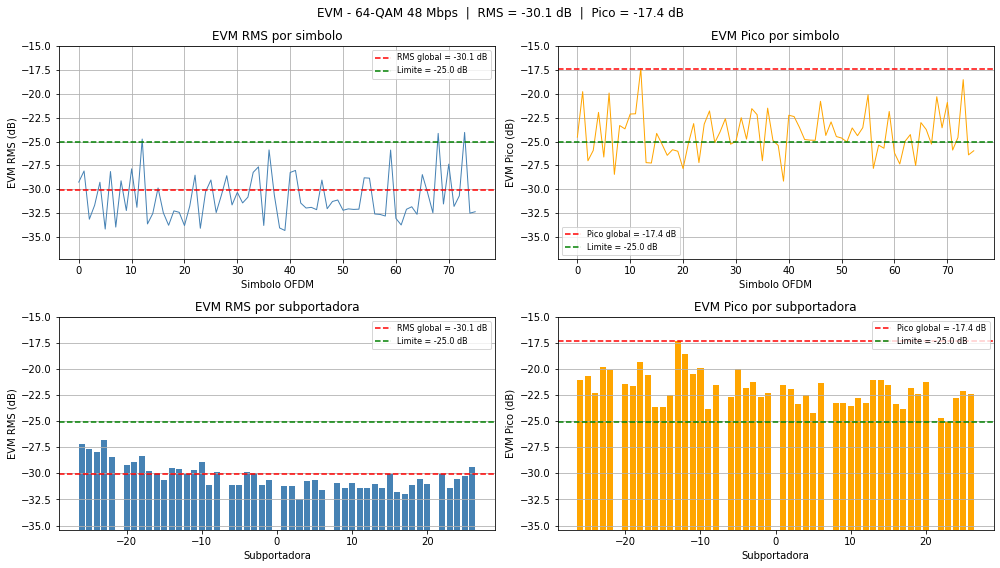

In [22]:
# EVM por simbolo y por portadora en dB
N_val = np.sum(mask_validas)
puntos_matrix = constelacion_corr[:, mask_validas]

# Decisor simbolo por simbolo
ideales_matrix = np.zeros_like(puntos_matrix)
for k in range(N_simbolos):
    ideales_matrix[k] = decisor_64qam_norm(puntos_matrix[k], niveles_norm)

evm_por_simbolo_matrix = np.abs(puntos_matrix - ideales_matrix) / np.sqrt(P_ref) * 100

# Por simbolo
evm_por_simbolo_rms  = np.sqrt(np.mean(evm_por_simbolo_matrix**2, axis=1))
evm_por_simbolo_peak = np.max(evm_por_simbolo_matrix, axis=1)

# Por portadora
evm_por_portadora_rms  = np.sqrt(np.mean(evm_por_simbolo_matrix**2, axis=0))
evm_por_portadora_peak = np.max(evm_por_simbolo_matrix, axis=0)

# Convertir a dB
def to_db(evm_pct):
    return 20 * np.log10(evm_pct / 100)

# Indices de subportadoras en orden -26..+26
data_idx_validos = np.array(data_idx)[mask_validas]
subportadoras_num = np.where(data_idx_validos < 32,
                             data_idx_validos,
                             data_idx_validos - 64)
orden = np.argsort(subportadoras_num)
sub_ordenadas = subportadoras_num[orden]
evm_rms_port_db  = to_db(evm_por_portadora_rms[orden])
evm_peak_port_db = to_db(evm_por_portadora_peak[orden])

# Limites en dB
limite_db  = to_db(5.6)    # -25.0 dB
evm_rms_db  = to_db(evm_rms)
evm_peak_db = to_db(evm_peak)

ffig, axes = plt.subplots(2, 2, figsize=(14, 8))

y_min_sim = min(to_db(evm_por_simbolo_rms).min(), to_db(evm_por_simbolo_peak).min()) - 3
y_max_sim = -15

y_min_port = evm_rms_port_db.min() - 3
y_max_port = -15

# --- EVM RMS por simbolo ---
axes[0,0].plot(to_db(evm_por_simbolo_rms), color='steelblue', linewidth=1)
axes[0,0].axhline(evm_rms_db, color='red',   linestyle='--', label=f'RMS global = {evm_rms_db:.1f} dB')
axes[0,0].axhline(limite_db,  color='green', linestyle='--', label=f'Limite = {limite_db:.1f} dB')
axes[0,0].set_ylim(y_min_sim, y_max_sim)
axes[0,0].set_ylabel("EVM RMS (dB)")
axes[0,0].set_xlabel("Simbolo OFDM")
axes[0,0].set_title("EVM RMS por simbolo")
axes[0,0].legend(fontsize=8)
axes[0,0].grid()

# --- EVM Pico por simbolo ---
axes[0,1].plot(to_db(evm_por_simbolo_peak), color='orange', linewidth=1)
axes[0,1].axhline(evm_peak_db, color='red',   linestyle='--', label=f'Pico global = {evm_peak_db:.1f} dB')
axes[0,1].axhline(limite_db,   color='green', linestyle='--', label=f'Limite = {limite_db:.1f} dB')
axes[0,1].set_ylim(y_min_sim, y_max_sim)
axes[0,1].set_ylabel("EVM Pico (dB)")
axes[0,1].set_xlabel("Simbolo OFDM")
axes[0,1].set_title("EVM Pico por simbolo")
axes[0,1].legend(fontsize=8)
axes[0,1].grid()

# --- EVM RMS por portadora ---
axes[1,0].bar(sub_ordenadas, evm_rms_port_db - y_min_port,
              bottom=y_min_port, color='steelblue', width=0.8)
axes[1,0].axhline(evm_rms_db, color='red',   linestyle='--', label=f'RMS global = {evm_rms_db:.1f} dB')
axes[1,0].axhline(limite_db,  color='green', linestyle='--', label=f'Limite = {limite_db:.1f} dB')
axes[1,0].set_ylim(y_min_port, y_max_port)
axes[1,0].set_ylabel("EVM RMS (dB)")
axes[1,0].set_xlabel("Subportadora")
axes[1,0].set_title("EVM RMS por subportadora")
axes[1,0].legend(fontsize=8)
axes[1,0].grid(axis='y')

# --- EVM Pico por portadora ---
axes[1,1].bar(sub_ordenadas, evm_peak_port_db - y_min_port,
              bottom=y_min_port, color='orange', width=0.8)
axes[1,1].axhline(evm_peak_db, color='red',   linestyle='--', label=f'Pico global = {evm_peak_db:.1f} dB')
axes[1,1].axhline(limite_db,   color='green', linestyle='--', label=f'Limite = {limite_db:.1f} dB')
axes[1,1].set_ylim(y_min_port, y_max_port)
axes[1,1].set_ylabel("EVM Pico (dB)")
axes[1,1].set_xlabel("Subportadora")
axes[1,1].set_title("EVM Pico por subportadora")
axes[1,1].legend(fontsize=8)
axes[1,1].grid(axis='y')

plt.suptitle(f"EVM - 64-QAM 48 Mbps  |  RMS = {evm_rms_db:.1f} dB  |  Pico = {evm_peak_db:.1f} dB", fontsize=12)
plt.tight_layout()
plt.show()

![Análisis Tektronix SignalVu](capturas/signalVu.BMP)
![Análisis Tektronix SignalVu](capturas/signalVu2.BMP)